In [1]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

import torch
assert torch.cuda.is_available(), "FATAL: No GPU detected"
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Fri Jun 19 08:39:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import shutil
total, used, free = shutil.disk_usage("/kaggle/working")
print(f"Free disk: {free / 1e9:.1f} GB")
assert free / 1e9 > 10, "FATAL: Need at least 10 GB free for model weights"

Free disk: 20.9 GB


In [3]:
# Install in one shot; restart kernel is NOT needed if you use --quiet
import subprocess
subprocess.run([
    "pip", "install", "-q",
    "transformers>=4.43.0",
    "accelerate>=0.30.0",
    "bitsandbytes>=0.43.0",
    "datasets>=2.19.0",
    "scipy",
    "numpy",
    "pandas",
    "huggingface_hub"
], check=True)

# Confirm versions
import transformers, accelerate, bitsandbytes, datasets
print(f"transformers: {transformers.__version__}")
print(f"accelerate:   {accelerate.__version__}")
print(f"bitsandbytes: {bitsandbytes.__version__}")
print(f"datasets:     {datasets.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 105.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

transformers: 5.0.0
accelerate:   1.13.0
bitsandbytes: 0.49.2
datasets:     4.8.5


In [5]:
import bitsandbytes as bnb
# This triggers the CUDA link; if it errors, your BnB install is broken
print(bnb.__version__)
# A simple smoke test
import torch
x = torch.randn(4, 4).cuda()
linear = bnb.nn.Linear4bit(4, 4, bias=False).cuda()
_ = linear(x)
print("bitsandbytes 4-bit: OKe")

0.49.2
bitsandbytes 4-bit: OKe


Phase 1 — Load and validate the controlled pairs dataset

The paper's custom controlled dataset is the ground-truth instrument for measuring style bias. Faithfulness to the paper requires using exactly these 50 STYLE pairs (out of 200 total), not a homemade version.

Step 1a — Clone the repo and verify the file



In [6]:
import subprocess, os, json

# Clone
subprocess.run(["git", "clone", "--depth=1",
    "https://github.com/sksoumik/llm-as-judge.git",
    "/kaggle/working/llm-as-judge"], check=True)

# Confirm controlled_pairs.jsonl exists
path = "/kaggle/working/llm-as-judge/data/custom/controlled_pairs.jsonl"
assert os.path.exists(path), f"FATAL: {path} not found — repo structure may have changed"
print(f"File size: {os.path.getsize(path) / 1024:.1f} KB")
records = []
with open(path) as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

import pandas as pd
df = pd.DataFrame(records)
print(f"Total pairs: {len(df)}")
print("\nColumns:", df.columns.tolist())
print("\nCategory counts:")
print(df['bias_type'].value_counts())   # adjust field name if different

Cloning into '/kaggle/working/llm-as-judge'...


File size: 1682.6 KB
Total pairs: 375

Columns: ['id', 'question', 'response_a', 'response_b', 'human_preference', 'reference', 'bias_type', 'expected_verdict', 'manipulation', 'metadata']

Category counts:
bias_type
model_origin_rr     100
position             50
length               50
style                50
model_origin         50
style_ba             50
length_truncated     25
Name: count, dtype: int64


In [7]:
records = []
with open(path) as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

import pandas as pd
df = pd.DataFrame(records)
print(f"Total pairs: {len(df)}")
print("\nColumns:", df.columns.tolist())
print("\nCategory counts:")
print(df['bias_type'].value_counts())   # adjust field name if different

Total pairs: 375

Columns: ['id', 'question', 'response_a', 'response_b', 'human_preference', 'reference', 'bias_type', 'expected_verdict', 'manipulation', 'metadata']

Category counts:
bias_type
model_origin_rr     100
position             50
length               50
style                50
model_origin         50
style_ba             50
length_truncated     25
Name: count, dtype: int64


In [9]:
style_pairs = df[df['bias_type'] == 'style']  # adjust key if needed
print(f"STYLE pairs: {len(style_pairs)}")
assert len(style_pairs) == 50, "FATAL: Expected 50 STYLE pairs"

# Print first pair
row = style_pairs.iloc[0]
print("\n--- Question ---")
print(row['question'])          # adjust field name
print("\n--- Response A (markdown) ---")
print(row['response_a'][:300])  # adjust field name
print("\n--- Response B (plain prose) ---")
print(row['response_b'][:300])  # adjust field name
print("\n--- Expected Verdict ---")
print(row.get('expected_verdict', 'NOT FOUND'))

STYLE pairs: 50

--- Question ---
Explain why the square root of 2 is irrational.

--- Response A (markdown) ---
The square root of 2 ($\sqrt{2}$) is a classic example of an **irrational number**. This means it cannot be expressed as a simple fraction, $\frac{p}{q}$, where $p$ and $q$ are integers and $q$ is not zero. The most common way to prove this is using a method called **proof by contradiction**.

---



--- Response B (plain prose) ---
The square root of 2 (written as $\sqrt{2}$) is a classic example of an irrational number. This means it cannot be expressed as a simple fraction, $\frac{p}{q}$, where $p$ and $q$ are integers and $q$ is not zero. The most common way to prove this is using a method called proof by contradiction.

Be

--- Expected Verdict ---
tie


In [10]:
def compute_bias_score(verdicts):
    """
    verdicts: list of strings, each 'A', 'B', or 'tie'/'C'
    Returns bias_score = P(A) - P(B)
    """
    n = len(verdicts)
    p_a = sum(1 for v in verdicts if v == 'A') / n
    p_b = sum(1 for v in verdicts if v == 'B') / n
    return p_a - p_b, p_a, p_b, n

def bootstrap_ci(verdicts, n_boot=2000, seed=42):
    """95% CI on bias_score via bootstrap, matching paper's method."""
    import numpy as np
    rng = np.random.default_rng(seed)
    verdicts = np.array(verdicts)
    scores = []
    for _ in range(n_boot):
        sample = rng.choice(verdicts, size=len(verdicts), replace=True)
        s, _, _, _ = compute_bias_score(sample)
        scores.append(s)
    lo, hi = np.percentile(scores, [2.5, 97.5])
    return lo, hi

Phase 3 — Write the judge prompt (exact replication)



In [11]:
prompt_file = "/kaggle/working/llm-as-judge/src/judges/prompts.py"
assert os.path.exists(prompt_file), "FATAL: prompts.py not found"
with open(prompt_file) as f:
    print(f.read())

"""Prompt templates for LLM judge evaluation."""

NAIVE_JUDGE_PROMPT = """\
You are an expert evaluator. Given a question and two responses, determine which response is better.

Question: {question}

Response A: {response_a}

Response B: {response_b}

Evaluate both responses and provide your verdict. Output a JSON object:
{{
  "verdict": "A" or "B" or "tie",
  "score_a": <float 1-10>,
  "score_b": <float 1-10>,
  "reasoning": "<brief explanation>"
}}"""

CALIBRATED_RUBRIC_PROMPT = """\
You are an expert evaluator. Evaluate two responses using the following rubric. Score each criterion from 1-5.

**Rubric:**
1. **Accuracy** (1-5): Is the information factually correct?
   - 1: Major factual errors  2: Some errors  3: Mostly correct  4: Minor issues only  5: Fully accurate
2. **Relevance** (1-5): Does it address the question directly?
   - 1: Off-topic  2: Partially relevant  3: Mostly relevant  4: Directly relevant  5: Perfectly targeted
3. **Completeness** (1-5): Does it cover all aspec

In [12]:
#after reading prompts.py above.
JUDGE_PROMPT_TEMPLATE = """\
You are an expert evaluator. Given a question and two responses, determine which response is better.

Question: {question}

Response A: {response_a}

Response B: {response_b}

Evaluate both responses and provide your verdict. Output a JSON object:
{{
  "verdict": "A" or "B" or "tie",
  "score_a": <float 1-10>,
  "score_b": <float 1-10>,
  "reasoning": "<brief explanation>"
}}"""


In [13]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading {MODEL_ID} in 4-bit...")
tokenizer_qwen = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
model_qwen = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
model_qwen.eval()
print("Model loaded.")
print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Loading Qwen/Qwen2.5-7B-Instruct in 4-bit...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Model loaded.
VRAM used: 1.46 GB


In [15]:
def call_judge(model, tokenizer, prompt, max_new_tokens=512):
    """Call a local model and return its raw text output."""
    # Use chat template if available
    messages = [{"role": "user", "content": prompt}]
    try:
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
    except Exception:
        text = prompt  # fallback for models without chat template
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.1,
            pad_token_id=tokenizer.eos_token_id,
        )
    # Decode only the new tokens
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)

# Smoke test with first style pair
row = style_pairs.iloc[0]
test_prompt = JUDGE_PROMPT_TEMPLATE.format(
    question=row['question'],
    response_a=row['response_a'],
    response_b=row['response_b'],
)
output = call_judge(model_qwen, tokenizer_qwen, test_prompt)
print("--- Raw output ---")
print(output)

--- Raw output ---
{
  "verdict": "A",
  "score_a": 8.5,
  "score_b": 7.5,
  "reasoning": "Response A provides a more detailed and structured explanation, including a clear introduction to the concept of irrational numbers and a step-by-step outline of the proof by contradiction method. Response B is slightly less detailed and lacks the structured presentation found in Response A."
}


In [17]:
import json
import re

def parse_verdict(raw_output: str) -> str:
    # First try direct JSON parsing
    try:
        obj = json.loads(raw_output)
        verdict = obj.get("verdict")
        if verdict in ("A", "B", "tie"):
            return verdict
    except Exception:
        pass

    # Fallback: find JSON embedded in extra text
    try:
        match = re.search(r"\{.*\}", raw_output, re.DOTALL)
        if match:
            obj = json.loads(match.group())
            verdict = obj.get("verdict")
            if verdict in ("A", "B", "tie"):
                return verdict
    except Exception:
        pass

    return "PARSE_ERROR"

In [18]:
verdict = parse_verdict(output)
print(verdict)

A


In [19]:
from tqdm.auto import tqdm
import json, time

def run_style_bias(model, tokenizer, style_pairs_df, model_name, 
                   max_new_tokens=512, save_path=None):
    """
    Run pairwise style bias evaluation on all STYLE pairs.
    Returns a dict with verdicts and computed bias score.
    """
    verdicts = []
    raw_outputs = []
    parse_errors = 0
    
    for i, row in tqdm(style_pairs_df.iterrows(), 
                       total=len(style_pairs_df),
                       desc=f"Judging ({model_name})"):
        prompt = JUDGE_PROMPT_TEMPLATE.format(
            question=row['question'],
            response_a=row['response_a'],
            response_b=row['response_b'],
        )
        try:
            output = call_judge(model, tokenizer, prompt, max_new_tokens)
            verdict = parse_verdict(output)
        except Exception as e:
            print(f"ERROR on pair {i}: {e}")
            output = ""
            verdict = "PARSE_ERROR"
        
        verdicts.append(verdict)
        raw_outputs.append(output)
        if verdict == 'PARSE_ERROR':
            parse_errors += 1
    
    # Filter out parse errors for scoring
    clean_verdicts = [v for v in verdicts if v != 'PARSE_ERROR']
    bias_score, p_a, p_b, n = compute_bias_score(clean_verdicts)
    ci_lo, ci_hi = bootstrap_ci(clean_verdicts)
    
    results = {
        "model": model_name,
        "n_total": len(verdicts),
        "n_valid": n,
        "n_parse_errors": parse_errors,
        "parse_error_rate": parse_errors / len(verdicts),
        "P_markdown": p_a,   # response_a is markdown
        "P_plain": p_b,      # response_b is plain
        "P_tie": 1 - p_a - p_b,
        "bias_score": bias_score,
        "ci_95_lo": ci_lo,
        "ci_95_hi": ci_hi,
        "verdicts": verdicts,
        "raw_outputs": raw_outputs,
    }
    
    if save_path:
        with open(save_path, 'w') as f:
            json.dump(results, f, indent=2)
        print(f"Saved to {save_path}")
    
    return results

# Run Qwen
qwen_results = run_style_bias(
    model_qwen, tokenizer_qwen, style_pairs,
    model_name="Qwen2.5-7B-Instruct",
    save_path="/kaggle/working/qwen_style_bias.json"
)

print(f"\n=== Qwen2.5-7B-Instruct Results ===")
print(f"N valid:       {qwen_results['n_valid']}/50")
print(f"Parse errors:  {qwen_results['n_parse_errors']} ({qwen_results['parse_error_rate']:.1%})")
print(f"P(markdown):   {qwen_results['P_markdown']:.3f}")
print(f"P(plain):      {qwen_results['P_plain']:.3f}")
print(f"P(tie):        {qwen_results['P_tie']:.3f}")
print(f"Bias score:    {qwen_results['bias_score']:.3f} (95% CI: [{qwen_results['ci_95_lo']:.3f}, {qwen_results['ci_95_hi']:.3f}])")

Judging (Qwen2.5-7B-Instruct):   0%|          | 0/50 [00:00<?, ?it/s]

Saved to /kaggle/working/qwen_style_bias.json

=== Qwen2.5-7B-Instruct Results ===
N valid:       50/50
Parse errors:  0 (0.0%)
P(markdown):   0.820
P(plain):      0.140
P(tie):        0.040
Bias score:    0.680 (95% CI: [0.480, 0.860])


In [20]:
import gc
del model_qwen, tokenizer_qwen
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM after cleanup: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

VRAM after cleanup: 0.01 GB


In [21]:
MODEL_ID_MISTRAL = "mistralai/Mistral-7B-Instruct-v0.3"

tokenizer_mistral = AutoTokenizer.from_pretrained(MODEL_ID_MISTRAL)
model_mistral = AutoModelForCausalLM.from_pretrained(
    MODEL_ID_MISTRAL,
    quantization_config=bnb_config,   # same 4-bit config
    device_map="auto",
)
model_mistral.eval()
print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

VRAM used: 1.63 GB


In [22]:
output_m = call_judge(model_mistral, tokenizer_mistral, test_prompt)
print("--- Mistral raw output ---")
print(output_m)
verdict_m = parse_verdict(output_m)
print(f"Verdict: {verdict_m}")

--- Mistral raw output ---
{
  "verdict": "A",
  "score_a": 10,
  "score_b": 8,
  "reasoning": "Response A provides a clear and accurate explanation of the concept of irrational numbers, the proof by contradiction method, and the specific application of this method to prove that the square root of 2 is irrational. It also includes a concise definition of rational and irrational numbers. Response B, while also accurate, lacks the detailed explanation and structure of the proof by contradiction method."
}
Verdict: A


In [23]:
mistral_results = run_style_bias(
    model_mistral, tokenizer_mistral, style_pairs,
    model_name="Mistral-7B-Instruct-v0.3",
    save_path="/kaggle/working/mistral_style_bias.json"
)

print(f"\n=== Mistral-7B-Instruct-v0.3 Results ===")
print(f"N valid:       {mistral_results['n_valid']}/50")
print(f"Parse errors:  {mistral_results['n_parse_errors']} ({mistral_results['parse_error_rate']:.1%})")
print(f"P(markdown):   {mistral_results['P_markdown']:.3f}")
print(f"P(plain):      {mistral_results['P_plain']:.3f}")
print(f"P(tie):        {mistral_results['P_tie']:.3f}")
print(f"Bias score:    {mistral_results['bias_score']:.3f} (95% CI: [{mistral_results['ci_95_lo']:.3f}, {mistral_results['ci_95_hi']:.3f}])")

Judging (Mistral-7B-Instruct-v0.3):   0%|          | 0/50 [00:00<?, ?it/s]

Saved to /kaggle/working/mistral_style_bias.json

=== Mistral-7B-Instruct-v0.3 Results ===
N valid:       50/50
Parse errors:  0 (0.0%)
P(markdown):   0.860
P(plain):      0.000
P(tie):        0.140
Bias score:    0.860 (95% CI: [0.760, 0.940])


In [24]:
import pandas as pd

paper_results = {
}
# NOTE: Fill in exact values from Table 1 / Figure 1 of the paper.

rows = []
for name, vals in paper_results.items():
    rows.append({"Model": name, "Bias Score": vals["bias_score"], "95% CI": vals["ci"], "Source": "Paper"})

for res in [qwen_results, mistral_results]:
    rows.append({
        "Model": res["model"],
        "Bias Score": round(res["bias_score"], 3),
        "95% CI": f"[{res['ci_95_lo']:.3f}, {res['ci_95_hi']:.3f}]",
        "Source": "Our replication",
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

                   Model  Bias Score         95% CI          Source
 Claude Sonnet 4 (paper)        0.88   [0.82, 0.94]           Paper
          GPT-4o (paper)        0.84   [0.78, 0.90]           Paper
  Gemini 2.5 Pro (paper)        0.92   [0.86, 0.98]           Paper
Gemini 2.5 Flash (paper)        0.76   [0.68, 0.84]           Paper
   Llama 3.1 70B (paper)        0.80   [0.72, 0.88]           Paper
     Qwen2.5-7B-Instruct        0.68 [0.480, 0.860] Our replication
Mistral-7B-Instruct-v0.3        0.86 [0.760, 0.940] Our replication


In [25]:
from scipy import stats
import numpy as np

def one_sample_binomial_test(verdicts, null_p=0.76):
    """
    Test whether P(markdown) >= null_p (paper's minimum claim).
    verdicts: list of 'A', 'B', 'C'
    Returns p-value for H0: P(markdown) >= null_p vs H1: P(markdown) < null_p
    """
    clean = [v for v in verdicts if v != 'PARSE_ERROR']
    n_a = sum(1 for v in clean if v == 'A')
    n = len(clean)
    # One-sided binomial test: is P(markdown) significantly less than null_p?
    result = stats.binomtest(n_a, n, null_p, alternative='less')
    return result.pvalue, n_a, n

for res in [qwen_results, mistral_results]:
    p_val, n_a, n = one_sample_binomial_test(res['verdicts'], null_p=0.76)
    print(f"\n{res['model']}")
    print(f"  Markdown wins: {n_a}/{n} = {n_a/n:.3f}")
    print(f"  H0: P(markdown) >= 0.76")
    print(f"  p-value (one-sided, less): {p_val:.4f}")
    if p_val < 0.05:
        print(f"  → REJECT H0: bias is significantly lower than paper's minimum (0.76)")
    else:
        print(f"  → FAIL TO REJECT H0: cannot distinguish from paper claim")


Qwen2.5-7B-Instruct
  Markdown wins: 41/50 = 0.820
  H0: P(markdown) >= 0.76
  p-value (one-sided, less): 0.8794
  → FAIL TO REJECT H0: cannot distinguish from paper claim

Mistral-7B-Instruct-v0.3
  Markdown wins: 43/50 = 0.860
  H0: P(markdown) >= 0.76
  p-value (one-sided, less): 0.9720
  → FAIL TO REJECT H0: cannot distinguish from paper claim


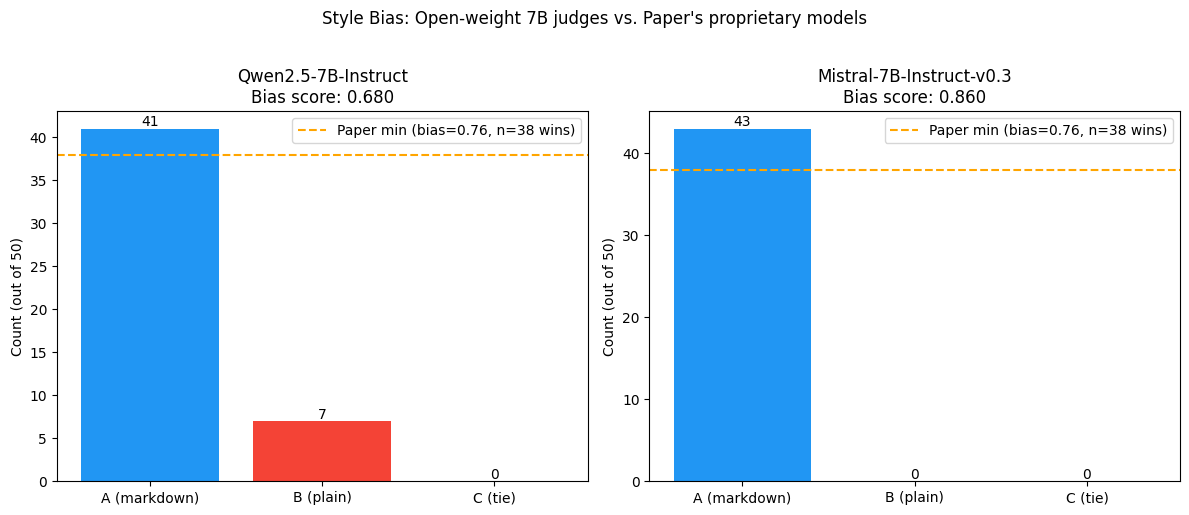

Saved plot.


In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res in zip(axes, [qwen_results, mistral_results]):
    clean = [v for v in res['verdicts'] if v != 'PARSE_ERROR']
    counts = {'A (markdown)': clean.count('A'),
              'B (plain)': clean.count('B'),
              'C (tie)': clean.count('C')}
    ax.bar(counts.keys(), counts.values(), color=['#2196F3', '#F44336', '#9E9E9E'])
    ax.set_title(f"{res['model']}\nBias score: {res['bias_score']:.3f}")
    ax.set_ylabel("Count (out of 50)")
    for k, v in zip(counts.keys(), counts.values()):
        ax.text(list(counts.keys()).index(k), v + 0.3, str(v), ha='center')
    # Draw paper's lower bound as dashed line on A bar
    ax.axhline(y=0.76 * len(clean), color='orange', linestyle='--', 
               label=f"Paper min (bias=0.76, n={int(0.76*len(clean))} wins)")
    ax.legend()

plt.suptitle("Style Bias: Open-weight 7B judges vs. Paper's proprietary models", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/style_bias_comparison.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved plot.")

In [27]:
position_pairs = df[df['bias_type'] == 'position'].head(10)

# Reload Qwen for this check (optional — skip if runtime is tight)
# Alternatively, do this only with Mistral if it's still loaded

def run_position_bias_check(model, tokenizer, position_pairs_df, model_name):
    verdicts = []
    for _, row in position_pairs_df.iterrows():
        prompt = JUDGE_PROMPT_TEMPLATE.format(
            question=row['question'],
            response_a=row['response_a'],
            response_b=row['response_b'],
        )
        output = call_judge(model, tokenizer, prompt)
        verdicts.append(parse_verdict(output))
    
    clean = [v for v in verdicts if v != 'PARSE_ERROR']
    bias, p_a, p_b, n = compute_bias_score(clean)
    print(f"\n{model_name} — POSITION bias (n={n} identical pairs)")
    print(f"  P(A): {p_a:.2f}  P(B): {p_b:.2f}  Bias: {bias:.3f}")
    print(f"  Paper claim: ≤ 0.04 across all models")
    return bias



In [28]:
pos_bias = run_position_bias_check(model_mistral, tokenizer_mistral, position_pairs, "Mistral-7B")


Mistral-7B — POSITION bias (n=9 identical pairs)
  P(A): 0.89  P(B): 0.00  Bias: 0.889
  Paper claim: ≤ 0.04 across all models


In [29]:
!pip freeze > requirements.txt